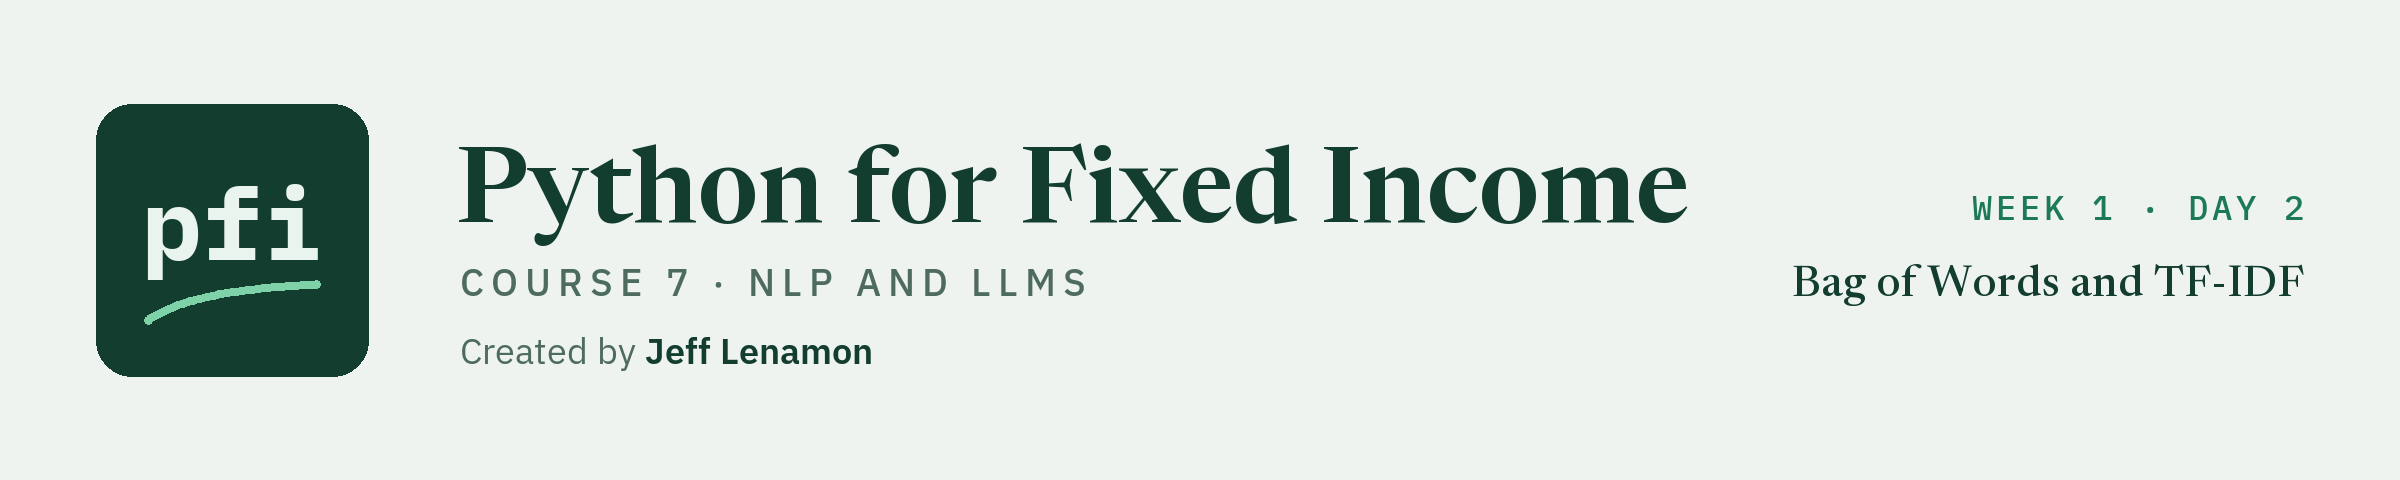

# Bag of Words and TF-IDF

Week 1, Day 2. Turn text into numbers you can compare: count words, weight them by how rare they are, and measure how alike two documents are, on the FOMC statements and on the covenants of a real indenture.

**Data:** `course7_fomc_statements.csv`, 226 FOMC post-meeting statements, 2000-02-02 to 2026-09-16: **real**, Board of Governors of the Federal Reserve System, public domain (federalreserve.gov).

**Data:** `course7_indentures/boyd_2021.txt`: Boyd Gaming Corporation, Indenture dated as of June 8, 2021, 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495: **real**, a public record on sec.gov, quoted for descriptive extraction only.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week1/day2/02_bag_of_words_and_tf_idf.ipynb)

Day 1 turned a statement into tokens. Today the tokens become numbers. Count every token of every document and you have a table, one row per document and one column per word: the **bag of words**. Weight each count by how rare the word is across the documents and you have **TF-IDF**, the weighting behind search engines and behind the classifier of day 3. Two rows of that table can then be compared with one number, the **cosine similarity**.

The same two documents as day 1: the 226 FOMC statements, and the Boyd Gaming indenture for the 4.750% Senior Notes due 2031, whose Article 4 sections become twenty small documents in section 2.6. Today's four `textkit` functions compute each step by hand and are tested against scikit-learn's to 1e-12, so when day 3 uses scikit-learn's vectorizer inside a pipeline, you know exactly what it computes.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** The FOMC statements are the Board of Governors' own text, public domain. The indenture is a public record on sec.gov, filed by its issuer. Both are quoted exactly as published, with a source line under every excerpt.
* **Described, never judged.** A term's weight in a statement is a number computed from the statement's words for a stated date, never a reading of what the Committee meant, will do, or should do. An indenture's terms are reported as the indenture states them, never called loose or tight, and no sentence compares issuers.
* **Issuer names appear only as the authors of the documents being read**: in the data line, the source line, and here.

**Rows.** No model is fitted or scored in this notebook: every number describes the 226 statements and the one indenture as published.

Today you will:

1. Count every token of every statement with `CountVectorizer` and with `term_counts`, and see the two agree.
2. Count in how many statements each word appears, and turn that into an inverse document frequency with `idf`.
3. Build TF-IDF by hand with `tfidf_by_hand`, check it against `TfidfVectorizer`, and change one setting at a time.
4. Measure how alike two statements are with `cosine_similarity_matrix`, and draw all 25,425 pairs.
5. Find the terms that set each year's statements apart.
6. Do the same on the sections of the indenture's Article 4.
7. See what a bag of words loses: the order of the words.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, the seed, and today's two data files.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_02_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_fomc_statements.csv", "course7_indentures/boyd_2021.txt"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_02_ojcnh082, in your temp folder
Data files from the data folder of the course repo: course7_fomc_statements.csv, course7_indentures/boyd_2021.txt
SEED = 42


* The same setup cell as day 1, line for line; day 1's notes explain each line. Today also runs no model, so there is no PyTorch line.

Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])

Writing textkit.py


In [4]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2

Writing test_textkit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 4


* `textkit.py` and `test_textkit.py` as day 1 left them: four functions and 7 tests. Today appends four more functions and their tests.

Q. Start today's repository now, before the lesson adds anything, so that at the end of the day Git can show exactly what today added.

In [6]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [7]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_02_ojcnh082 and nowhere else


In [8]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [9]:
!git -C "{work}" add .gitignore mlkit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Start of day 2: textkit as day 1 left it, 7 tests"
!git -C "{work}" log --oneline

e03f571 Start of day 2: textkit as day 1 left it, 7 tests


* The same start and the same `.gitignore` as day 1. The first commit holds the module as it stands at the start of today; Save the Day with Git, at the end, reads the difference.

## 2.1 Bag of Words

A **bag of words** forgets the order of a document's words and keeps only how often each one occurs, as if the words were shaken into a bag and counted. Every statement becomes one row of counts, every distinct token in all the statements one column.

Most statements end with the vote: a paragraph that names each member who voted. A table of words would then hold people's names as columns, and this course never tabulates a person. So today counts the words of each statement without those paragraphs.

Q. Load the statements, normalize them, and leave out the paragraphs that name members.

In [10]:
import collections
import re

fomc = pd.read_csv("course7_fomc_statements.csv")


def statement_source(row):
    """The source line for one statement of the file."""
    return (f"Source: FOMC post-meeting statement of {row['date']}, Board of Governors of the Federal Reserve "
            f"System, {row['url']}")


# a paragraph that names members: the vote ("Voting for ...", "Voting against ..."), or a member named by title
VOTE = re.compile(r"Voting|voting|Governor [A-Z]|President [A-Z]")


def policy_text(text):
    """A statement normalized, without the paragraphs that name members."""
    paragraphs = textkit.normalize_text(text).split("\n")
    return "\n".join(p for p in paragraphs if not VOTE.search(p))


docs = [policy_text(t) for t in fomc["text"]]
paragraphs_out = sum(bool(VOTE.search(p)) for t in fomc["text"] for p in textkit.normalize_text(t).split("\n"))
print(f"statements: {len(docs)}; paragraphs left out: {paragraphs_out}")
print(f"tokens of the first statement: {len(textkit.tokenize(docs[0]))}")

statements: 226; paragraphs left out: 212
tokens of the first statement: 190


* 212 paragraphs are left out, from 199 statements. Every other word of every statement is kept, normalized as on day 1.

Q. Count every token of every statement with scikit-learn's `CountVectorizer`, using the course's token pattern.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# demonstration: the vectorizer is fitted on all statements only to describe them; nothing is scored
counter = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN)
bag = counter.fit_transform(docs)
vocabulary = list(counter.get_feature_names_out())
print(f"rows (statements): {bag.shape[0]}; columns (distinct tokens): {bag.shape[1]:,}")
# most entries are 0: a statement uses a small part of the whole vocabulary
print(f"share of the table that is not 0: {bag.nnz / (bag.shape[0] * bag.shape[1]):.4f}")
print(f"the first ten columns: {vocabulary[:10]}")

rows (statements): 226; columns (distinct tokens): 1,686
share of the table that is not 0: 0.0983
the first ten columns: ['0', '0.00', '1', '1-1', '1-3', '1.25', '1.70', '10', '100', '11']


* 226 rows by 1,686 columns, and only 9.8 percent of the table is not 0. scikit-learn stores such a table as a **sparse matrix**, which keeps only the entries that are not 0; `toarray()` turns it into an ordinary array when one is needed.
* `fit` learns the vocabulary, the list of columns, sorted alphabetically: the digits come first. `transform` counts. `fit_transform` does both. The comment `demonstration` says the vectorizer is fitted here only to describe the documents. From day 3, where a model is scored, every vectorizer is fitted inside a `Pipeline` on the training rows only.

Q. Add `term_counts` to `textkit.py`: the same table, computed with `tokenize`. Then its test.

In [12]:
%%writefile -a textkit.py


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)

Appending to textkit.py


In [13]:
%%writefile -a test_textkit.py


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2

Appending to test_textkit.py


* `import numpy as np` sits above the function because today's functions are the first in `textkit` to use arrays. Python reads an import wherever it is in a module, as long as it runs before the function is used.
* `term_counts` tokenizes each document, then adds 1 to the cell of each token's column. With `vocabulary` it counts only the terms given, in that order; without it, every token found, sorted.
* The test compares it with `CountVectorizer` on four short sentences, cell by cell.

Q. Reload `textkit` and run the tests.

In [14]:
importlib.reload(textkit)
print(f"term_counts in textkit: {hasattr(textkit, 'term_counts')}")

term_counts in textkit: True


In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........                                                                 [100%]
8 passed in 1.52s



* `8 passed`: day 1's 7 and the new one.

Q. Does `term_counts` give the same table as `CountVectorizer` on all 226 statements?

In [16]:
counts = textkit.term_counts(docs, vocabulary)
print(f"shape: {counts.shape}; every cell equal to CountVectorizer's: {(counts.to_numpy() == bag.toarray()).all()}")
print(f"the same columns without a vocabulary: {list(textkit.term_counts(docs).columns) == vocabulary}")
# four columns of three statements: the first, the first that uses "pandemic" (2020-09-16), and the last
print(counts.loc[[0, 177, 225], ['inflation', 'growth', 'pandemic', 'mortgage-backed']].to_string())

shape: (226, 1686); every cell equal to CountVectorizer's: True
the same columns without a vocabulary: True
     inflation  growth  pandemic  mortgage-backed
0            1       3         0                0
177         10       0         1                1
225          1       1         0                0


* Equal in every cell. The table reads as it looks: in the first statement "inflation" counts 1 and "pandemic" 0; in the statement of 2020-09-16, "inflation" counts 10 and "pandemic" 1. A row sums to the statement's number of tokens (190 for the first).

Q. `CountVectorizer` does not run `normalize_text`. What changes if it reads the text as published?

In [17]:
# source text: quoted as published
# the same paragraphs, as published: not normalized
raw_docs = ["\n".join(p for p in t.split("\n") if not VOTE.search(textkit.normalize_text(p))) for t in fomc["text"]]
# demonstration: fitted only to compare two vocabularies
raw_vocabulary = set(CountVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(raw_docs).get_feature_names_out())
print(f"columns from the raw text: {len(raw_vocabulary):,}; from the normalized text: {len(vocabulary):,}")
print(f"only in the normalized text: {sorted(set(vocabulary) - raw_vocabulary)}")
print(f"only in the raw text: {sorted(raw_vocabulary - set(vocabulary))}")
# ascii() shows each character outside ASCII as its escape
dash_text = fomc.loc[fomc["date"] == "2020-03-15", "text"].iloc[0]
start = dash_text.index("banks")
print(f"2020-03-15, as published: {ascii(dash_text[start - 12:start + 12])}")
survey = next(t for t in raw_docs if "survey" + chr(0x2011) + "based" in t)
start = survey.index("survey")
print(f"the one raw 'survey': {ascii(survey[start:start + 20])}")
print(statement_source(fomc.loc[fomc["date"] == "2020-03-15"].iloc[0]))

columns from the raw text: 1,686; from the normalized text: 1,686
only in the normalized text: ['and-in', 'banks-the']
only in the raw text: ['s', 'survey']
2020-03-15, as published: 'her central banks\u2014the U.'
the one raw 'survey': 'survey\u2011based measure'
Source: FOMC post-meeting statement of 2020-03-15, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/newsevents/pressreleases/monetary20200315a.htm


* The vocabularies differ by four columns, and each one is a look-alike character from day 1.
* On the raw text, "s" is a column of its own: the raw text writes an "s" after the curly apostrophe U+2019 22 times ("Committee's" among them), and the token pattern joins words only on the keyboard apostrophe, so the "s" after it is cut off as a token. After `normalize_text` the apostrophe is plain and "committee's" stays one token.
* Also on the raw text, "survey" with the non-breaking hyphen is not joined to "based": the token pattern's `[-'.]` holds the keyboard hyphen only, so the raw text gives a column "survey" that the normalized text, where the word is "survey-based", does not.
* The other way round, the statement of 2020-03-15 writes two em dashes with no spaces around them. `normalize_text` makes each a hyphen, as its map says, and the token pattern then joins the words on either side: "and-in" and "banks-the". The map is right for the hyphens it was written for and makes two odd tokens here. A rule applied to every document shows where it fits and where it does not, which is why the course prints what it finds.

## 2.2 Document Frequency and IDF

A raw count makes "the" the heaviest word of every statement. The fix is to weight each word by how many documents it appears in. The **document frequency** of a term, `df`, is the number of documents that hold it at least once; the **inverse document frequency**, `idf`, is large for a term in few documents and small for a term in many.

> **STORY: a paper on how specific a term is.** In January 1972 Karen Sparck Jones published a paper titled "A statistical interpretation of term specificity and its application in retrieval" in the *Journal of Documentation* (volume 28, issue 1, pages 11 to 21). Its title speaks of the specificity of a term and of retrieval, finding the documents that match a request; section 2.2 measures a term by the share of documents it appears in. The paper itself was not read for this course, so the notebook says nothing about the method it sets out.
>
> Source (read 2026-10-08): the Crossref record of the paper, https://api.crossref.org/works/10.1108/eb026526, DOI 10.1108/eb026526. Only the title, author, journal, volume, issue, pages, and year are taken from it.

Q. In how many statements does each token appear?

In [18]:
# a cell above 0 means the statement holds the token; summing True down each column counts the statements
doc_freq = (counts.to_numpy() > 0).sum(axis=0)
frequency = pd.Series(doc_freq, index=vocabulary)
print(f"tokens in every one of the {len(docs)} statements: {list(frequency[frequency == len(docs)].index)}")
print(f"tokens in exactly one statement: {(frequency == 1).sum()}")

tokens in every one of the 226 statements: ['and', 'federal', 'market', 'the', 'to']
tokens in exactly one statement: 404


* 5 tokens appear in every statement, and 404 appear in only one. A word in every document cannot tell one document from another.

Q. Add `idf` to `textkit.py`, and its two tests. Read the formula in the docstring first.

In [19]:
%%writefile -a textkit.py


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0

Appending to textkit.py


In [20]:
%%writefile -a test_textkit.py


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)

Appending to test_textkit.py


* `idf = ln((1 + n) / (1 + df)) + 1`, with `n` the number of documents and `ln` the natural log. This is scikit-learn's default, `smooth_idf=True`. The two `1 +` inside act as if one extra document held every term once, so no `df` is ever 0 in a division. The `+ 1` outside keeps a term that is in every document at a weight of 1, not 0, so it still counts a little.
* A term in every one of the 226 statements gets `ln(227 / 227) + 1 = 1.0`; a term in one statement gets `ln(227 / 2) + 1 = 5.7318`, the largest weight possible here.
* The second test makes sure a `df` above `n`, or below 0, stops with `ValueError`: such a number is a bug upstream, and a weight computed from it would look plausible.

Q. Reload and run the tests.

In [21]:
importlib.reload(textkit)
print(f"idf in textkit: {hasattr(textkit, 'idf')}")

idf in textkit: True


In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........                                                               [100%]
10 passed in 1.37s



* `10 passed`.

Q. Compute the weights for the statements, check them against `TfidfVectorizer`'s `idf_`, and show five terms.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

weights = pd.Series(textkit.idf(doc_freq, len(docs)), index=vocabulary)
# demonstration: fitted only to read its idf_, one weight per column, in the same alphabetical order
plain = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(docs)
print(f"same columns: {list(plain.get_feature_names_out()) == vocabulary}; "
      f"idf within 1e-12 of idf_: {np.abs(weights.to_numpy() - plain.idf_).max() < 1e-12}")
show = ['the', 'committee', 'inflation', 'pandemic', 'mortgage-backed']
print(pd.DataFrame({"statements": frequency[show], "idf": weights[show].round(4)}).to_string())

same columns: True; idf within 1e-12 of idf_: True
                 statements     idf
the                     226  1.0000
committee               225  1.0044
inflation               205  1.0971
pandemic                 19  3.4292
mortgage-backed         108  1.7336


* Equal to 1e-12. "the" is in all 226 statements and weighs 1.0; "committee" misses one statement and weighs 1.0044; "inflation" is in 205 and weighs 1.0971; "pandemic", in 19, weighs 3.4292. The weight grows slowly: it is a log, so a term in a tenth as many documents gains about 2.3, not ten times.

## 2.3 TF-IDF by Hand

**TF-IDF** is term frequency times inverse document frequency: each count multiplied by its column's weight. Then each row is scaled to length 1 (divided by the square root of the sum of its squares), so a long statement and a short one can be compared on the same footing.

Q. Add `tfidf_by_hand` to `textkit.py`, and its two tests.

In [24]:
%%writefile -a textkit.py


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)

Appending to textkit.py


In [25]:
%%writefile -a test_textkit.py


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)

Appending to test_textkit.py


* The weights come from the counts themselves: `(tf > 0).sum(axis=0)` is the document frequency, as in section 2.2.
* `sublinear=True` replaces each count above 0 by `1 + ln(count)`, so a word used ten times weighs about 3.3 times a word used once, not 10 times.
* A row of zeros (a document with none of the vocabulary's terms) would be divided by a length of 0 and become NaN, "not a number", which spreads into every later sum. The function divides it by 1 instead, and the second test checks it stays zero.

Q. Reload and run the tests.

In [26]:
importlib.reload(textkit)
print(f"tfidf_by_hand in textkit: {hasattr(textkit, 'tfidf_by_hand')}")

tfidf_by_hand in textkit: True


In [27]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

............                                                             [100%]
12 passed in 1.43s



* `12 passed`.

Q. Does `tfidf_by_hand` equal `TfidfVectorizer` on all the statements, with and without `sublinear`?

In [28]:
by_hand = textkit.tfidf_by_hand(counts)
print(f"plain: within 1e-12 of TfidfVectorizer: {np.abs(by_hand - plain.transform(docs).toarray()).max() < 1e-12}")
# demonstration: fitted only to compare with the hand computation
sub = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=True).fit(docs)
by_hand_sub = textkit.tfidf_by_hand(counts, sublinear=True)
print(f"sublinear: within 1e-12 of TfidfVectorizer: {np.abs(by_hand_sub - sub.transform(docs).toarray()).max() < 1e-12}")
print(f"every row has length 1: {np.allclose(np.linalg.norm(by_hand, axis=1), 1.0, rtol=0, atol=1e-12)}")

plain: within 1e-12 of TfidfVectorizer: True
sublinear: within 1e-12 of TfidfVectorizer: True
every row has length 1: True


* Equal to 1e-12, both ways. Nothing in `TfidfVectorizer` is hidden now: counts, weights from document frequency, and rows of length 1.

Q. Which five terms of the first statement are the largest by count, by TF-IDF, and by TF-IDF with `sublinear`?

In [29]:
# source text: quoted as published
first_counts = counts.loc[0].sort_values(ascending=False, kind="stable").head(5)
# np.lexsort sorts by its last key first: the weight, largest first (hence the minus), then the term, for ties
order = np.lexsort((np.array(vocabulary), -by_hand[0]))[:5]
first_tfidf = pd.Series(by_hand[0, order], index=[vocabulary[k] for k in order]).round(4)
order = np.lexsort((np.array(vocabulary), -by_hand_sub[0]))[:5]
first_sub = pd.Series(by_hand_sub[0, order], index=[vocabulary[k] for k in order]).round(4)
# int() and float() print plain numbers
print("by count:", {term: int(v) for term, v in first_counts.items()})
print("by TF-IDF:", {term: float(v) for term, v in first_tfidf.items()})
print("by TF-IDF with sublinear_tf:", {term: float(v) for term, v in first_sub.items()})
print(statement_source(fomc.iloc[0]))

by count: {'the': 19, 'of': 8, 'in': 7, 'federal': 5, 'rate': 5}
by TF-IDF: {'the': 0.4506, 'of': 0.1906, 'discount': 0.1832, 'in': 0.1675, 'reserve': 0.149}
by TF-IDF with sublinear_tf: {'pronounced': 0.1686, 'discount': 0.159, 'record': 0.1567, '5-3': 0.1482, 'borrow': 0.1482}
Source: FOMC post-meeting statement of 2000-02-02, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/


* By count the first statement is mostly "the", "of", and "in", as every statement is. Plain TF-IDF still puts "the" first: its weight is only 1.0, but the statement uses it 19 times, and a rarer word used once or twice cannot catch up. "discount" does reach third place.
* With `sublinear`, 19 uses of "the" count as `1 + ln(19)`, about 3.9, and "the" leaves the top five. The heaviest term becomes "pronounced", used once here and in no other statement. That is what the weighting is for, and why the course's setting turns `sublinear_tf` on.
* Ties are broken by the term, alphabetically, with `np.lexsort`, so the order never depends on how a sort happens to break a tie (the course's rule for every ranking).

Q. scikit-learn's defaults, then the course's settings one at a time: how many columns does each give?

In [30]:
settings = [
    ("scikit-learn's defaults", {}),
    ("the course's token pattern", {"token_pattern": textkit.TOKEN_PATTERN}),
    ("+ sublinear_tf=True", {"token_pattern": textkit.TOKEN_PATTERN, "sublinear_tf": True}),
    ("+ min_df=2", {"token_pattern": textkit.TOKEN_PATTERN, "sublinear_tf": True, "min_df": 2}),
    ("+ ngram_range=(1, 2)", {"token_pattern": textkit.TOKEN_PATTERN, "sublinear_tf": True, "min_df": 2,
                              "ngram_range": (1, 2)}),
]
rows = []
for label, keywords in settings:
    # demonstration: each vectorizer is fitted only to count its columns
    rows.append({"setting": label, "columns": len(TfidfVectorizer(**keywords).fit(docs).vocabulary_)})
print(pd.DataFrame(rows).to_string(index=False))
# demonstration: the default vocabulary, to see what its pattern does to two of the course's tokens
default_vocabulary = set(TfidfVectorizer().fit(docs).get_feature_names_out())
both_parts = {"mortgage", "backed"} <= default_vocabulary
print(f'"mortgage-backed" in the default columns: {"mortgage-backed" in default_vocabulary}; '
      f'"mortgage" and "backed": {both_parts}')
print(f"one-character tokens in the course's columns: {sum(len(t) == 1 for t in vocabulary)}")

                   setting  columns
   scikit-learn's defaults     1614
the course's token pattern     1686
       + sublinear_tf=True     1686
                + min_df=2     1282
      + ngram_range=(1, 2)     6143


"mortgage-backed" in the default columns: False; "mortgage" and "backed": True
one-character tokens in the course's columns: 10


* **The default token pattern** keeps runs of two or more letters or digits and splits at every hyphen, so "mortgage-backed" becomes "mortgage" and "backed", and the one-character tokens (10 of them in the course's columns, digits of the rates among them) are dropped: 1,614 columns against the course pattern's 1,686. Day 1 chose the course's pattern; this is where the choice shows.
* **`sublinear_tf`** changes the weights, not the columns (1,686).
* **`min_df=2`** drops every term that appears in only one statement: 1,282 columns. A term seen once cannot show anything two documents share.
* **`ngram_range=(1, 2)`** adds every pair of neighbouring tokens, a **bigram**, such as "federal funds", as a column of its own: 6,143 columns. Bigrams keep a little of the word order a bag of words throws away (section 2.7).
* The last line is the course's setting from now on: the one `textkit.text_classifier` uses on day 3.

## 2.4 Cosine Similarity

Two rows of TF-IDF are two lists of numbers, one per column. Their **cosine similarity** is the sum of their products divided by the product of their lengths: 1 when the two lists point the same way (the same words in the same proportions), 0 when they share no term. A cosine measures how alike two documents' words are; it is not a probability.

Q. Add `cosine_similarity_matrix` to `textkit.py`, and its two tests.

In [31]:
%%writefile -a textkit.py


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T

Appending to textkit.py


In [32]:
%%writefile -a test_textkit.py


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0

Appending to test_textkit.py


* Each row is divided by its length, then one matrix product `@` multiplies every row of A with every row of B, so one line gives every pair at once.
* A row of zeros gives 0 with every row, never NaN, for the same reason as in `tfidf_by_hand`.

Q. Reload and run all of today's tests.

In [33]:
importlib.reload(textkit)
print(f"cosine_similarity_matrix in textkit: {hasattr(textkit, 'cosine_similarity_matrix')}")

cosine_similarity_matrix in textkit: True


In [34]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............                                                           [100%]
14 passed in 1.41s



* `14 passed`: day 1's 7 and today's 7.

Q. With the course's setting, which two statements are most alike, and which two least?

In [35]:
# demonstration: the course's setting, fitted on all statements only to describe them
course = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=True, min_df=2, ngram_range=(1, 2))
matrix = course.fit_transform(docs).toarray()
course_vocabulary = list(course.get_feature_names_out())
similarity = textkit.cosine_similarity_matrix(matrix)
print(f"similarity matrix: {similarity.shape}; the diagonal (each statement with itself): "
      f"{np.allclose(np.diag(similarity), 1.0, rtol=0, atol=1e-12)}")
# every pair once (i before j), largest first, ties by the rows
pairs = sorted((-similarity[i, j], i, j) for i in range(len(docs)) for j in range(i + 1, len(docs)))
dates = list(fomc["date"])
for label, (score, i, j) in (("most alike", pairs[0]), ("least alike", pairs[-1])):
    print(f"{label}: {dates[i]} and {dates[j]}, cosine {-score:.4f}")
following = [similarity[k, k + 1] for k in range(len(docs) - 1)]
print(f"median cosine of a statement with the next one: {np.median(following):.4f}; of all pairs: "
      f"{np.median(similarity[np.triu_indices(len(docs), 1)]):.4f}")

similarity matrix: (226, 226); the diagonal (each statement with itself): True
most alike: 2024-01-31 and 2024-03-20, cosine 0.9699
least alike: 2004-03-16 and 2010-05-09, cosine 0.0241
median cosine of a statement with the next one: 0.7731; of all pairs: 0.1129


* The most alike pair is 2024-01-31 and 2024-03-20, cosine 0.9699: two statements of the same year that share almost all their words. The least alike are 2004-03-16 and 2010-05-09, 0.0241.
* A statement and the next one have a median cosine of 0.7731; any two statements, 0.1129. Neighbouring statements reuse each other's wording. The numbers describe the text, not what the Committee did or meant.

Q. Show the start of the two most alike statements.

In [36]:
# source text: quoted as published
for k in (204, 205):
    print(docs[k][:260])
    print(statement_source(fomc.iloc[k]))
    print()

Recent indicators suggest that economic activity has been expanding at a solid pace. Job gains have moderated since early last year but remain strong, and the unemployment rate has remained low. Inflation has eased over the past year but remains elevated.
The 
Source: FOMC post-meeting statement of 2024-01-31, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/newsevents/pressreleases/monetary20240131a.htm

Recent indicators suggest that economic activity has been expanding at a solid pace. Job gains have remained strong, and the unemployment rate has remained low. Inflation has eased over the past year but remains elevated.
The Committee seeks to achieve maximum
Source: FOMC post-meeting statement of 2024-03-20, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/newsevents/pressreleases/monetary20240320a.htm



Q. Draw every pair as a heat map, statements in date order on both axes.

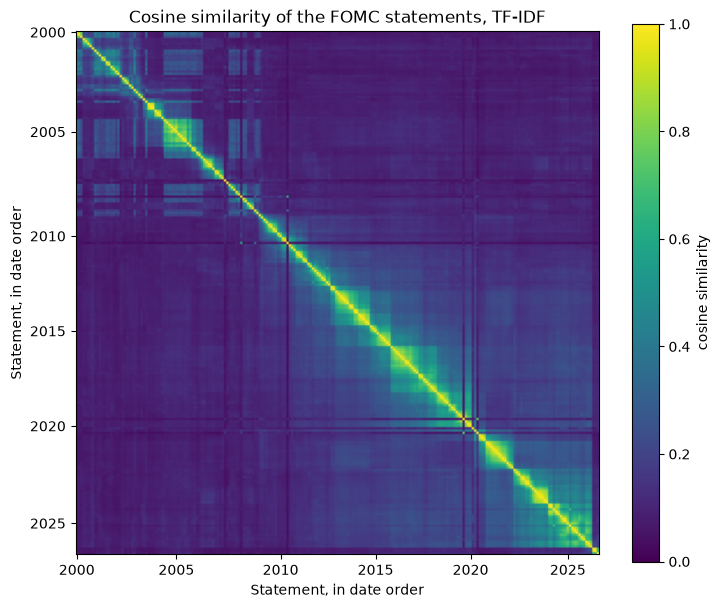

2010-05-09, an unscheduled release: median cosine with the others 0.0441
2007-08-10, an unscheduled release: median cosine with the others 0.0601
2008-03-11, an unscheduled release: median cosine with the others 0.0680


In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 6.2))
image = ax.imshow(similarity, cmap="viridis", vmin=0, vmax=1)
# a tick at the first statement of every fifth year
years = fomc["date"].str[:4].astype(int)
ticks = [int(np.argmax(years.to_numpy() == y)) for y in range(2000, 2027, 5)]
ax.set_xticks(ticks, [str(y) for y in range(2000, 2027, 5)])
ax.set_yticks(ticks, [str(y) for y in range(2000, 2027, 5)])
ax.set_title("Cosine similarity of the FOMC statements, TF-IDF")
ax.set_xlabel("Statement, in date order")
ax.set_ylabel("Statement, in date order")
fig.colorbar(image, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.show()
# the statements least like all the others: the lowest median cosine with the rest
median_with_others = np.nanmedian(np.where(np.eye(len(docs), dtype=bool), np.nan, similarity), axis=1)
for k in np.argsort(median_with_others, kind="stable")[:3]:
    kind = "after a scheduled meeting" if fomc["scheduled"][k] else "an unscheduled release"
    print(f"{dates[k]}, {kind}: median cosine with the others {median_with_others[k]:.4f}")

* Bright squares along the diagonal are runs of statements that reuse each other's words; where one square ends, the wording changed. The thin dark lines across the whole map are single statements that share little wording with any other: the three least like the rest are unscheduled releases (2010-05-09, 2007-08-10, 2008-03-11). The heat map shows when the wording changed, by date. It does not say why, and the course does not read it for policy.

## 2.5 Distinctive Terms by Year

Q. For each year, which three terms have the largest mean TF-IDF in that year's statements, compared with the mean in every other statement?

In [38]:
# source text: quoted as published
years = fomc["date"].str[:4].astype(int).to_numpy()
terms = np.array(course_vocabulary)
distinctive = {}
for year in sorted(set(years)):
    inside = years == year
    # the mean weight in this year's statements, minus the mean in all the others
    difference = matrix[inside].mean(axis=0) - matrix[~inside].mean(axis=0)
    distinctive[int(year)] = ", ".join(terms[np.lexsort((terms, -difference))[:3]])
# one line per year: the year, then its three terms
for year, year_terms in distinctive.items():
    print(f"{year}: {year_terms}")
print("Source: FOMC post-meeting statements, 2000-02-02 to 2026-09-16, Board of Governors of the Federal Reserve System, federalreserve.gov")

2000: heightened inflation, generate heightened, heightened
2001: 50 basis, discount rate, 50
2002: the information, rate unchanged, unchanged at
2003: in inflation, policy coupled, an unwelcome
2004: believes that, perceives the, equal
2005: action the, contained the, action
2006: be needed, any, that some
2007: has the, core inflation, pace over
2008: to growth, housing contraction, labor markets
2009: markets the, conditions in, up to
2010: stable inflation, resource, of resource
2011: at levels, its securities, investment in
2012: inflation over, committee also, stronger economic
2013: asset, purchases, a highly
2014: asset, asset purchase, purchase program
2015: market indicators, declines in, declines
2016: declines in, declines, actual
2017: actual, conditions will, and expected
2018: further gradual, strong, symmetric
2019: symmetric 2, symmetric, inflation near
2020: support the, stability goals, flow
2021: by at, percent for, on vaccinations
2022: war, demand imbalances, imba

* A term is distinctive for a year when that year's statements weight it more than the rest of the file does. 2013 and 2014 are about "asset" and "purchases"; 2021 has "on vaccinations"; 2022 has "war". These are words the statements wrote in those years, nothing more.
* Some rows show the tokenizer at work: 2026's "3-3" is the front of "3-3/4", cut at the slash (day 1 chose that; numbers are read with patterns, not tokens). A table like this is a quick way to find such pieces before a model takes them in.

## 2.6 The Same Tools on an Indenture

Article 4 of the Boyd indenture holds its covenants, twenty sections from 4.01 to 4.20. Each section is now one document.

Q. Find Article 4's sections, and count "indebtedness" in each.

In [39]:
# source text: quoted as published
BOYD = ("Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed "
        "2021-06-08, accession 0001193125-21-185495")


def boyd_source(section=None):
    """The source line for an excerpt of the Boyd indenture."""
    return f"Source: {BOYD}" + (f", Section {section}." if section else ".")


indenture = Path("course7_indentures/boyd_2021.txt").read_text(encoding="utf-8")
sections = textkit.find_sections(indenture)
article_4 = sections[sections["number"].str.startswith("4.")].reset_index(drop=True)
section_texts = [indenture[s:e] for s, e in zip(article_4["start"], article_4["end"])]
section_counts = textkit.term_counts(section_texts)
section_df = (section_counts.to_numpy() > 0).sum(axis=0)
section_idf = pd.Series(textkit.idf(section_df, len(section_texts)), index=section_counts.columns)
table = pd.DataFrame({"title": article_4["title"].str[:40], "indebtedness": section_counts["indebtedness"]})
table.index = article_4["number"]
print(table.to_string())
print(f'sections that hold "indebtedness": {(section_counts["indebtedness"] > 0).sum()} of {len(section_texts)}; '
      f'its idf: {section_idf["indebtedness"]:.4f}')
print(f"terms in every section: {list(section_idf[section_idf == 1.0].index)}; "
      f"the largest idf possible here: {np.log((1 + len(section_texts)) / 2) + 1:.4f}")
print(boyd_source())

                                           title  indebtedness
number                                                        
4.01                            Payment of Notes             0
4.02             Maintenance of Office or Agency             0
4.03                                     Reports             0
4.04                      Compliance Certificate             0
4.05                     Stay and Extension Laws             0
4.06                         Corporate Existence             0
4.07    Limitation on Status as an Investment Co             0
4.08                                  [Reserved]             0
4.09                  Additional Note Guarantees             3
4.10                           Change of Control             0
4.11                                 Asset Sales            10
4.12                  Limitation on Indebtedness            67
4.13          Limitation on Layered Indebtedness             7
4.14                         Limitation on Liens       

* "Indebtedness" is in 9 of the 20 sections, and in 8 of the 11 from 4.10 to 4.20, where the restrictive covenants are: its idf is 1.7419, against 3.3514 for a term in one section. Only "section" is in all twenty. So across the covenants the word is common and its weight is about half the largest; what makes it heavy in 4.12 is the count, 67, the largest of any section. TF-IDF needs both halves: a common word used many times in one place.
* The word counted here is the lower-case token, so the defined term "Indebtedness" and the ordinary word are one column. Day 1 kept capitals for that reason; a bag of words, as usually built, does not.

Q. Which sections of Article 4 are most alike, and what are 4.12's heaviest terms?

In [40]:
# source text: quoted as published
# demonstration: the course's setting on the twenty sections, only to describe them
section_tfidf = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=True, min_df=2, ngram_range=(1, 2))
section_matrix = section_tfidf.fit_transform(section_texts).toarray()
section_terms = np.array(section_tfidf.get_feature_names_out())
section_similarity = textkit.cosine_similarity_matrix(section_matrix)
numbers = list(article_4["number"])
n = len(numbers)
section_pairs = sorted((-section_similarity[i, j], i, j) for i in range(n) for j in range(i + 1, n))[:5]
print(pd.DataFrame([{"section": numbers[i], "and": numbers[j], "cosine": round(-s, 4)} for s, i, j in section_pairs])
      .to_string(index=False))
row = numbers.index("4.12")
print("4.12, heaviest terms:", list(section_terms[np.lexsort((section_terms, -section_matrix[row]))[:8]]))
first, second = section_pairs[0][1], section_pairs[0][2]
shared = np.minimum(section_matrix[first], section_matrix[second])
print(f"terms {numbers[first]} and {numbers[second]} share most:", list(section_terms[np.lexsort((section_terms, -shared))[:6]]))
print(boyd_source())

section  and  cosine
   4.10 4.11  0.5688
   4.12 4.15  0.5330
   4.12 4.16  0.4663
   4.11 4.15  0.4554
   4.11 4.12  0.4353
4.12, heaviest terms: ['reference', 'first', 'the first', 'incurred', 'indebtedness', 'permitted refinancing', 'refinancing indebtedness', 'incurrence']
terms 4.10 and 4.11 share most: ['offer', 'notes or', 'or portions', 'portions', 'portions thereof', 'securities laws']
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


* The most alike pair is 4.10 and 4.11, cosine 0.5688: Change of Control and Asset Sales, two sections that each set out an offer to the holders (the "Change of Control Offer" and the "Prepayment Offer") and share its wording ("offer", "notes or", "or portions"). Next come 4.12 and 4.15, 0.5330.
* "indebtedness" is number 5 among 4.12's heaviest terms, beside bigrams such as "permitted refinancing". The cosines describe shared wording only; they say nothing about what the sections permit.

## 2.7 What a Bag of Words Loses

An indenture's meaning often sits in a few small words in a fixed order: "not less than" is a floor, "less than" a ceiling.

Q. Two sentences, written for this course, use the same words in a different order and state opposite tests. How alike are they as bags of words, of bigrams, and of trigrams (three neighbouring tokens)?

In [41]:
sentences = ["Leverage is less than 3.0 and coverage is not less than 2.0.",
             "Leverage is not less than 3.0 and coverage is less than 2.0."]
print(f"the same token counts: {(textkit.term_counts(sentences).loc[0] == textkit.term_counts(sentences).loc[1]).all()}")
for n in (1, 2, 3):
    # demonstration: two sentences, counted to compare them
    pair_counts = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, ngram_range=(1, n)).fit_transform(sentences)
    print(f"tokens up to {n} in a row: cosine {textkit.cosine_similarity_matrix(pair_counts.toarray())[0, 1]:.4f}")

the same token counts: True
tokens up to 1 in a row: cosine 1.0000
tokens up to 2 in a row: cosine 1.0000
tokens up to 3 in a row: cosine 0.9512


* As bags of words the two sentences are the same vector, cosine 1.0000, although one sets a floor where the other sets a ceiling. Bigrams do not separate them either (1.0000): both sentences hold "is not", "not less", "is less", and "less than", only attached to different subjects. Trigrams do (0.9512), because "leverage is less" and "leverage is not" differ.
* So a bag of words is a good index of what a document is about and a poor reader of what it says. Week 2's models take the order of words into account, and week 3 reads covenant tests from the text itself, with the quote beside every number.

## Excel Side by Side

Excel has no tokenizer and no TF-IDF function, so it cannot build today's table from text. What it can do is every step after the counts: given a column of counts and a column of document frequencies, `LN` gives the weight, a product gives TF-IDF, `SQRT(SUMSQ())` scales a row to length 1, and `SUMPRODUCT` gives a cosine. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) on today's own text: the 226 statements as this notebook counts them in A2:A227, the 123 distinct tokens of the first statement in column H as text, with their counts in I and their document frequencies in J (pasted from `term_counts`), and the two most alike statements' TF-IDF rows in columns P and Q, one row per column of the course's vocabulary (6,143 rows).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Statements that hold a word | `sum("inflation" in d.lower() for d in docs)` | `=COUNTIF(A2:A227,"*inflation*")` | 205 |
| A criteria of 255 characters | | `=COUNTIF(A2:A227,REPT("a",255))` | 0 |
| A criteria of 256 characters | | `=COUNTIF(A2:A227,REPT("a",256))` | `#VALUE!` |
| IDF of one term | `textkit.idf(doc_freq, 226)` | `=LN((1+226)/(1+J2))+1` | within 1e-12 of `idf_`, all 123 terms |
| Count times IDF | `counts * weights` | `=I2*K2` | |
| Row scaled to length 1 | `textkit.tfidf_by_hand(counts)` | `=L2/SQRT(SUMSQ(L$2:L$124))` | within 1e-12, all 123 terms |
| Cosine of two rows | `textkit.cosine_similarity_matrix` | `=SUMPRODUCT(P1:P6143,Q1:Q6143)/(SQRT(SUMSQ(P1:P6143))*SQRT(SUMSQ(Q1:Q6143)))` | 0.9699, within 1e-12 |

**COUNTIF is Excel's document frequency, of a substring.** `COUNTIF` with `*` on both sides counts the cells that hold "inflation" anywhere, in any case: 205, equal to Python's count of statements whose text holds it. It counts letters, not tokens, so "inflationary" alone would count too (day 1's trap); here the two agree, because every statement that holds the letters also holds the whole word, which is why the token document frequency is also 205. It worked on cells of up to 5,456 characters. The limit is on the criteria, the text you search for: with 255 characters `COUNTIF` returned a count, with 256 it returned `#VALUE!`.

**IDF and TF-IDF.** Column K holds `=LN((1+226)/(1+J2))+1` filled down: the formula of section 2.2 with 226 statements, read from the document frequency in J. Its largest gap from `TfidfVectorizer`'s `idf_` over the 123 terms was 0.0. Column L multiplies count by weight, and column M divides each cell by the length of the whole column, `SQRT(SUMSQ(L$2:L$124))`; the `$` keeps the range fixed while the formula is filled down. M equals `tfidf_by_hand`'s first row with a largest gap of 0.0. The terms the statement does not hold are 0 and add nothing to `SUMSQ`, so the 123 rows are the whole row.

**Cosine.** `SUMPRODUCT` multiplies two columns cell by cell and adds the products; divided by the two lengths, it is the cosine. On the pasted rows of 2024-01-31 and 2024-03-20 it returned 0.9699, within 1.9e-15 of `cosine_similarity_matrix`. In the Excel column the token "2" and the token "2.0" must stay text: column H was formatted as Text before anything was written, and every term read back unchanged.

Q. Do Excel's numbers equal Python's on the same text?

In [42]:
# Excel's results, from the course's Excel check, beside Python's for the same text
first_weights = by_hand[0]
excel = {"COUNTIF inflation": 205,
         "COUNTIF, 256-character criteria": '#VALUE!',
         "LN idf of the": 1.0,
         "LN idf of inflation": 1.0970738486918215,
         "LN idf of the": 1.0,
         "row value of the": 0.4506175147777635,
         "row value of inflation": 0.026018983748693932,
         "row value of the": 0.4506175147777635,
         "SUMPRODUCT cosine": 0.9699303454293011}
python = {"COUNTIF inflation": sum("inflation" in d.lower() for d in docs),
          "COUNTIF, 256-character criteria": "#VALUE!"}
for term in ['the', 'inflation', 'the']:
    python[f"LN idf of {term}"] = weights[term]
    python[f"row value of {term}"] = first_weights[vocabulary.index(term)]
python["SUMPRODUCT cosine"] = similarity[204, 205]
side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["equal or within 1e-12"] = [a == b if isinstance(a, (int, str)) else abs(a - b) < 1e-12
                                         for a, b in zip(side_by_side["Excel"], side_by_side["Python"])]
# ten decimals: the 16th digit of a product can differ between machines
print(side_by_side.to_string(formatters={"Excel": lambda v: f"{v:.10f}" if isinstance(v, float) else str(v),
                                         "Python": lambda v: f"{v:.10f}" if isinstance(v, float) else str(v)}))

                                        Excel        Python  equal or within 1e-12
COUNTIF inflation                         205           205                   True
COUNTIF, 256-character criteria       #VALUE!       #VALUE!                   True
LN idf of the                    1.0000000000  1.0000000000                   True
LN idf of inflation              1.0970738487  1.0970738487                   True
row value of the                 0.4506175148  0.4506175148                   True
row value of inflation           0.0260189837  0.0260189837                   True
SUMPRODUCT cosine                0.9699303454  0.9699303454                   True


* Every row equal, or within 1e-12. Excel can check every number of today's pipeline once the counts exist; the counting itself, the tokens, is the part Python has to do.
* `COUNTIF` takes a criteria of at most 255 characters, so a search for a whole sentence of an indenture needs another tool; week 3's checked table uses `SEARCH`, which day 12 tests.

## Save the Day with Git

The repository started this morning with `textkit.py` as day 1 left it. Ask Git what today changed, then commit.

Q. Which files changed, and by how many lines?

In [43]:
# the data files are copies and stay untracked
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M test_textkit.py
 M textkit.py
?? course7_fomc_statements.csv
?? course7_indentures/


 test_textkit.py | 62 ++++++++++++++++++++++++++++++++++++++++
 textkit.py      | 88 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 150 insertions(+)


Q. Read the change to `textkit.py`.

In [44]:
# lines starting with + were added; a line starting with - would be one removed
!git -C "{work}" diff textkit.py

diff --git a/textkit.py b/textkit.py
index 951ea4a..6c855d5 100644
--- a/textkit.py
+++ b/textkit.py
@@ -119,3 +119,91 @@ def defined_terms(text: str) -> pd.DataFrame:
     rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
             for m in re.finditer(pattern, text)]
     return pd.DataFrame(rows, columns=["term", "start", "kind"])
+
+
+import numpy as np  # arrays, from day 2
+
+
+def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
+    """Count each term in each document: the bag of words.
+
+    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
+    found, with the columns sorted alphabetically).
+    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
+    missing from a document counts 0.
+    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
+ 

* Every line starts with `+`: today only added to the module, and not one of day 1's lines changed. That is the rule of `textkit`, "fragments only append": a later day can rely on every earlier function staying exactly as it was tested. A `-` line in this diff would be the first thing to read.

Q. Commit the two files.

In [45]:
!git -C "{work}" add textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Add term_counts, idf, tfidf_by_hand, cosine_similarity_matrix, 14 tests"
!git -C "{work}" log --oneline

8eaee35 Add term_counts, idf, tfidf_by_hand, cosine_similarity_matrix, 14 tests
e03f571 Start of day 2: textkit as day 1 left it, 7 tests


## Bring It Home

Add today's four functions to your own `textkit.py` in `my_bondmath`. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder, activate the course's environment, and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
& "$HOME\projects\python-fixed-income\.venv\Scripts\Activate.ps1"
code textkit.py
code test_textkit.py
```

**Step 2.** Paste the code of the four `%%writefile -a textkit.py` cells (sections 2.1 to 2.4), without their first lines, at the end of `textkit.py`, one after the other; do the same for the four `test_textkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `14 passed`.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git diff textkit.py
git add textkit.py test_textkit.py
git commit -m "Add term_counts, idf, tfidf_by_hand, cosine_similarity_matrix, 14 tests"
git log --oneline -3
```

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Turn documents into a bag of words with `CountVectorizer` and with `term_counts`, and say what a sparse matrix is.
* Count document frequencies and compute scikit-learn's smooth IDF by hand with `idf`, and say why a word in every document weighs 1, not 0.
* Build TF-IDF by hand with `tfidf_by_hand`, check it against `TfidfVectorizer` to 1e-12, and say what `sublinear_tf`, `min_df`, and `ngram_range` each change.
* Measure how alike two documents are with `cosine_similarity_matrix`, and draw every pair as a heat map.
* Find the terms that set a group of documents apart, on statements by year and on an indenture's sections.
* Say what a bag of words loses, and show it with two sentences that get the same vector.
* Compute IDF, TF-IDF, and a cosine in Excel with `LN`, `SQRT(SUMSQ())`, and `SUMPRODUCT`, and a document frequency of a substring with `COUNTIF`.

Next, day 3: a TF-IDF classifier that assigns an 8-K section its item, fitted inside a pipeline and scored on the sections filed in 2024.

## Exercises

The exercises use the 226 statements, described only: weights and cosines of their words for stated dates, never a reading of what the Committee meant. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the statements as the lesson counts them, builds the course's TF-IDF matrix of section 2.4, and defines `check`, a small function that marks your answers.

In [46]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# the statements as today's lesson counts them: normalized, without the paragraphs that name members
fomc = pd.read_csv("course7_fomc_statements.csv")
VOTE = re.compile(r"Voting|voting|Governor [A-Z]|President [A-Z]")
docs = ["\n".join(p for p in textkit.normalize_text(t).split("\n") if not VOTE.search(p)) for t in fomc["text"]]
dates = list(fomc["date"])
years = fomc["date"].str[:4].astype(int).to_numpy()


def statement_source(row):
    """The source line for one statement of the file."""
    return (f"Source: FOMC post-meeting statement of {row['date']}, Board of Governors of the Federal Reserve "
            f"System, {row['url']}")


# demonstration: the course's setting of section 2.4, fitted on all statements only to describe them
course = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=True, min_df=2, ngram_range=(1, 2))
matrix = course.fit_transform(docs).toarray()
course_vocabulary = list(course.get_feature_names_out())
print(f"statements: {len(docs)}; course matrix: {matrix.shape}")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

statements: 226; course matrix: (226, 6143)


### Exercise 1

Q. Fit a `TfidfVectorizer` with the course's token pattern and `stop_words="english"` (scikit-learn's list of 318 stop words), every other setting at its default, on all the statements; say `demonstration` in a comment. Store its number of columns in **ex1_columns**. Then take the mean TF-IDF of each column over the statements of 2008, and store the five terms with the largest means, ties by term, as a list in **ex1_terms**.

In [47]:
ex1_columns = ...
ex1_terms = ...

In [48]:
check("Exercise 1 columns", ex1_columns, 1529)
check("Exercise 1 the five terms of 2008", ex1_terms, ['growth', 'markets', 'economic', 'action', 'promote'])

Exercise 1 columns: not attempted yet
Exercise 1 the five terms of 2008: not attempted yet


### Exercise 2

Q. Using `matrix` from the setup cell and `textkit.cosine_similarity_matrix`, find the two statements of 2020 that are most alike. Store their dates, earlier first, as a tuple in **ex2_pair**, and their cosine in **ex2_cosine**.

In [49]:
ex2_pair = ...
ex2_cosine = ...

In [50]:
check("Exercise 2 the pair", ex2_pair, ('2020-09-16', '2020-11-05'))
check("Exercise 2 the cosine", ex2_cosine, 0.9519659304636653)

Exercise 2 the pair: not attempted yet
Exercise 2 the cosine: not attempted yet


### Exercise 3

Q. Add a function to your module. `top_tfidf_terms(matrix, vocabulary, row, n=5)` returns a Series of the `n` largest weights of one row, indexed by term, largest first, with equal weights in alphabetical order of the term; it raises `ValueError` if the matrix is not two-dimensional, the vocabulary does not match its columns, the row is outside the matrix, or `n` is below 1. Write the docstring first. Then add `test_top_tfidf_terms_ties_by_term`, with a tie on a small hand matrix and both errors. Run pytest, reload the module, and store the three heaviest terms of the last statement in `matrix`, as a list, in **ex3_terms**.

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [51]:
%%writefile -a textkit.py


# Exercise 3: write top_tfidf_terms(matrix, vocabulary, row, n) below this line

Appending to textkit.py


In [52]:
%%writefile -a test_textkit.py


# Exercise 3: write test_top_tfidf_terms_ties_by_term() below this line

Appending to test_textkit.py


In [53]:
# run pytest, reload the module, then run your function
ex3_terms = ...

In [54]:
check("Exercise 3 the three terms of the last statement", ex3_terms, ['0 vote', '12', '12 0'])

Exercise 3 the three terms of the last statement: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that computes the inverse document frequency, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Inverse document frequency of each term, with scikit-learn's smoothing.

    Inputs: doc_freq, the number of documents each term appears in; n_docs, the number of documents.
    Output: one weight per term, ln((1 + n_docs) / (1 + df)) + 1, the natural log. A term in every document
    weighs 1.0, never 0; a rarer term weighs more. Equal to TfidfVectorizer().idf_ (smooth_idf=True, the
    default) within 1e-12.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a plausible weight for every term, and contains one bug.

In [55]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def inverse_document_frequency(doc_freq, n_docs):
    """Inverse document frequency of each term, with scikit-learn's smoothing.

    Inputs: doc_freq, the number of documents each term appears in; n_docs, the number of documents.
    Output: one weight per term, ln((1 + n_docs) / (1 + df)) + 1, the natural log. A term in every document
    weighs 1.0, never 0; a rarer term weighs more. Equal to TfidfVectorizer().idf_ (smooth_idf=True, the
    default) within 1e-12.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    # how rare each term is: the number of documents over the number that hold it, on a log scale
    return np.log10(n_docs / df)

Q. Before you run the next cell: how many terms will the function give a weight of exactly 0, and will the first statement's heaviest term stay the same as section 2.3 found?

In [56]:
# the lesson's count table, recomputed here so the exercise stands on its own
vocabulary = sorted({token for d in docs for token in textkit.tokenize(d)})
counts = textkit.term_counts(docs, vocabulary).to_numpy()
doc_freq = (counts > 0).sum(axis=0)
weights = inverse_document_frequency(doc_freq, len(docs))
print(f"terms with a weight of 0: {(weights == 0).sum()}")
for label, w in (("this function", weights), ("textkit.idf", textkit.idf(doc_freq, len(docs)))):
    row = counts[0] * w
    print(f"the first statement's heaviest term with {label}: {vocabulary[np.lexsort((np.array(vocabulary), -row))[0]]}")

terms with a weight of 0: 5
the first statement's heaviest term with this function: pronounced
the first statement's heaviest term with textkit.idf: the


Q. Test the function against its docstring before you trust it: its weights must equal `TfidfVectorizer`'s `idf_` within 1e-12.

In [57]:
# the test, written from the docstring before the code is trusted
# demonstration: the vectorizer is fitted only to read its idf_
reference = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(docs)
counts = textkit.term_counts(docs, list(reference.get_feature_names_out()))
weights = inverse_document_frequency((counts.to_numpy() > 0).sum(axis=0), len(docs))
gap = np.abs(weights - reference.idf_).max()
assert gap < 1e-12, f"largest gap from idf_: {gap:.4f}; the smallest weight: {weights.min():.4f}, where idf_ has 1.0"
print("equal to TfidfVectorizer's idf_ within 1e-12")

AssertionError: largest gap from idf_: 3.3777; the smallest weight: 0.0000, where idf_ has 1.0

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the first statement's heaviest term, with the fixed function, in **ex4_top**.

In [58]:
# fix the function above and run the test again, then store the answer
ex4_top = ...

In [59]:
check("Exercise 4 the heaviest term with the fixed function", ex4_top, 'the')

Exercise 4 the heaviest term with the fixed function: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```